### Library and function imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data processing

In [2]:
df = pd.read_csv("dataset.csv")

# drop the empty column
df = df.iloc[:, [x for x in range(df.shape[1]) if x != 26]]

mask = (df.iloc[:, 3] == "Non-VinUnian").values

df.iloc[mask, 4:25] = df.iloc[mask, 26:].values
df = df.iloc[:, :25]

df.columns = [
    "timestamp",
    "age",
    "gender",
    "college",
    "year_of_study",
    "gpa_range",
    "currently_employed",
    "leisure_hours",
    "self_study_hours",
    "study_environment",
    "sleep_hours",
    "impact_on_learning_progress",
    "far_away_deadlines",
    "study_plan",
    "start_early_when_necessary",
    "difficult_to_maintain",
    "data_quality_check",
    "comfort_or_convenience",
    "peers_consider_normal",
    "control_over_habit",
    "sooner_next_month",
    "delay_until_deadline",
    "focus_frequency",
    "delay_unenjoyable_assignments",
    "referrer",
]

df.head()

,timestamp,age,gender,college,year_of_study,gpa_range,currently_employed,leisure_hours,self_study_hours,study_environment,...,difficult_to_maintain,data_quality_check,comfort_or_convenience,peers_consider_normal,control_over_habit,sooner_next_month,delay_until_deadline,focus_frequency,delay_unenjoyable_assignments,referrer
0,14/05/2026 0:28:00,19,Male,CECS (Engineering & Computer Science),1st Year,3.5 – 4.0,No,2.0,4.0,"Private space (i.e. bedroom, home office)",...,Somewhat Agree,Somewhat Disagree,Agree,Somewhat Agree,Somewhat Agree,Neutral,Somewhat Agree,5.0,4.0,Nguyễn Cảnh Kỳ
1,14/05/2026 0:30:30,19,Female,CBM (Business and Management),1st Year,3.5 – 4.0,Yes,2.0,8.0,"Private space (i.e. bedroom, home office)",...,Strongly Disagree,Somewhat Disagree,Strongly Disagree,Somewhat Disagree,Neutral,Strongly Agree,Disagree,4.0,5.0,Đặng Tuấn Kiệt
2,14/05/2026 0:30:32,19,Male,CECS (Engineering & Computer Science),1st Year,3.0 – 3.49,No,4.0,3.0,Open learning space (i.e. university library),...,Disagree,Somewhat Disagree,Somewhat Disagree,Somewhat Disagree,Neutral,Neutral,Disagree,3.0,4.0,Đặng Tuấn Kiệt
3,14/05/2026 0:31:18,18,Male,CECS (Engineering & Computer Science),1st Year,2.5 – 2.99,No,2.0,5.0,"Private space (i.e. bedroom, home office)",...,Somewhat Agree,Somewhat Agree,Somewhat Agree,Neutral,Somewhat Agree,Somewhat Agree,Somewhat Agree,5.0,5.0,Nguyễn Trọng Nhân
4,14/05/2026 0:32:25,19,Male,CECS (Engineering & Computer Science),1st Year,3.0 – 3.49,No,5.0,4.0,"Private space (i.e. bedroom, home office)",...,Neutral,Somewhat Disagree,Strongly Agree,Somewhat Disagree,Neutral,Strongly Disagree,Neutral,5.0,6.0,Nguyễn Trọng Nhân


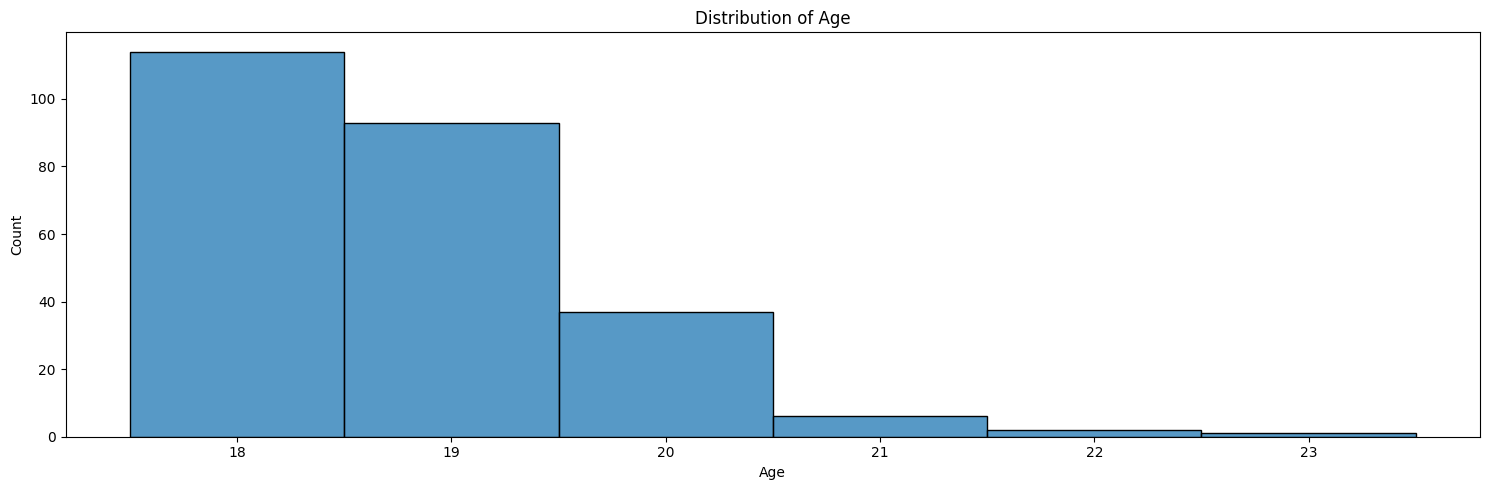

In [3]:
# Histogram of age
plt.figure(figsize=(15, 5))

sns.histplot(df["age"], discrete=True)
plt.title("Distribution of Age")

plt.tight_layout()
plt.xlabel("Age")
plt.show()

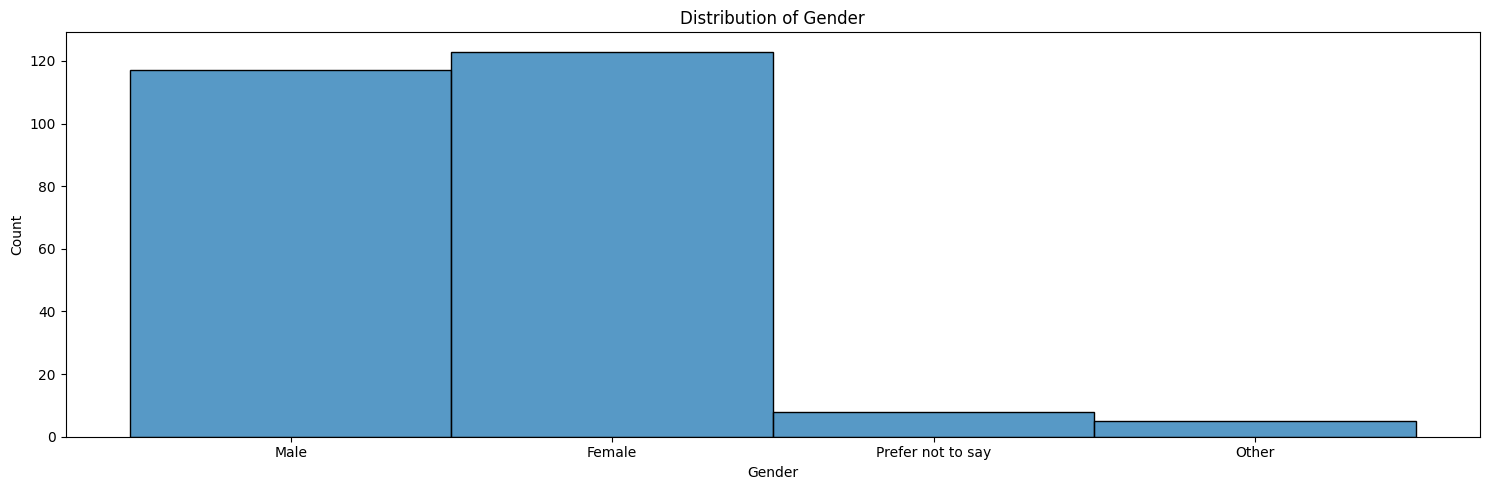

In [4]:
# Histogram of gender
plt.figure(figsize=(15, 5))

sns.histplot(df["gender"])
plt.title("Distribution of Gender")

plt.tight_layout()
plt.xlabel("Gender")
plt.show()

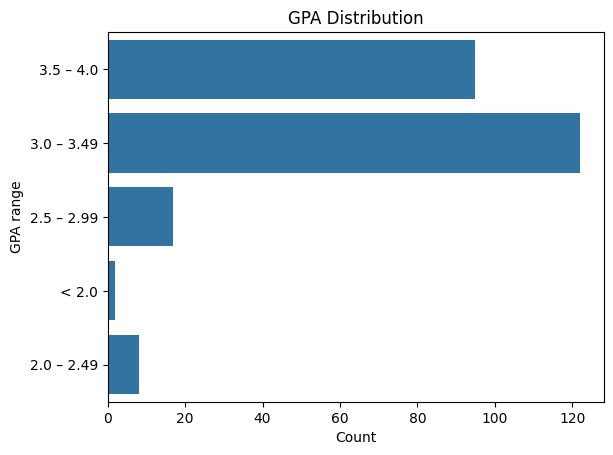

In [5]:
# Visulization of gpa
sns.countplot(data=df["gpa_range"])
plt.title("GPA Distribution")
plt.xlabel("Count")
plt.ylabel("GPA range")
plt.show()

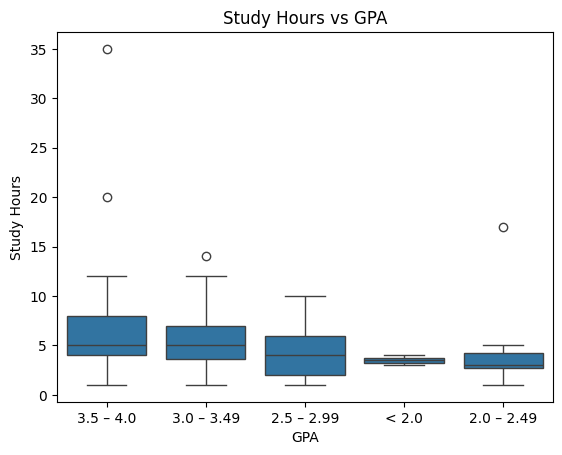

In [6]:
# Correlation between gpa and self-studying hours
sns.boxplot(x=df["gpa_range"], y=df["self_study_hours"], data=df)
plt.title("Study Hours vs GPA")
plt.xlabel("GPA")
plt.ylabel("Study Hours")
plt.show()

In [7]:
df['study_environment'] = df['study_environment'].str.strip()

study_environment_map = {
    "Private space (i.e. bedroom, home office)": "Private Space",
    "Open learning space (i.e. university library)": "Open Space",
    "Collaborative space (i.e. group study room)": "Collab Space",
    "Cafes": "Café",
    
    "Dormitory": "Private Space",
    "Any quiet space": "Private Space",
    "Flexible": "Flexible/Multiple",
    "Flexible, could be private place or open learning space": "Flexible/Multiple",
    "All above": "Flexible/Multiple",
    "all places above, and all places possible like pantry rooms, JA102, etc": "Flexible/Multiple"
}

df['study_environment'] = df['study_environment'].map(study_environment_map)
print(df['study_environment'].value_counts())

study_environment
Private Space        135
Open Space            53
Café                  29
Collab Space          22
Flexible/Multiple      5
Name: count, dtype: int64


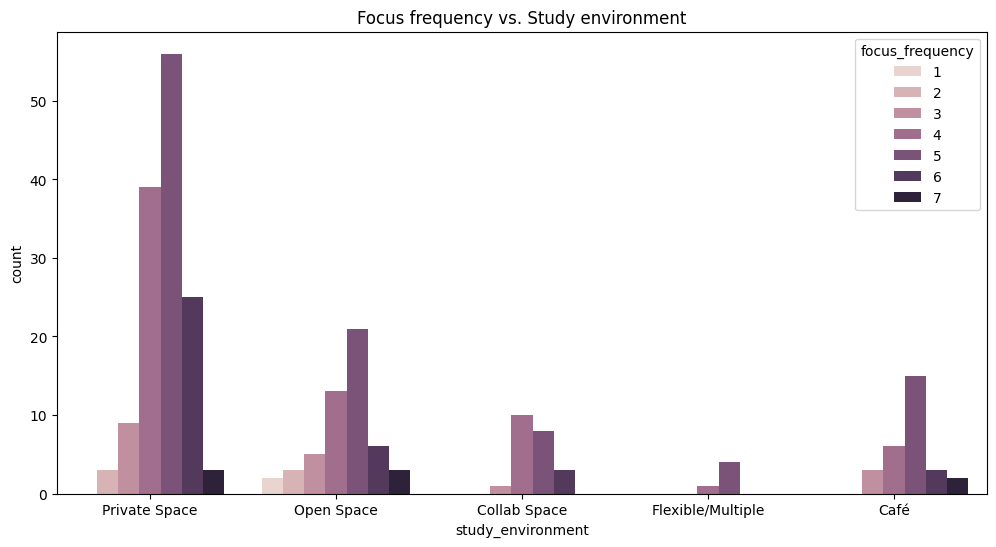

In [8]:
# Plot study location vs focus
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='study_environment', hue='focus_frequency')
plt.title('Focus frequency vs. Study environment')
plt.show()

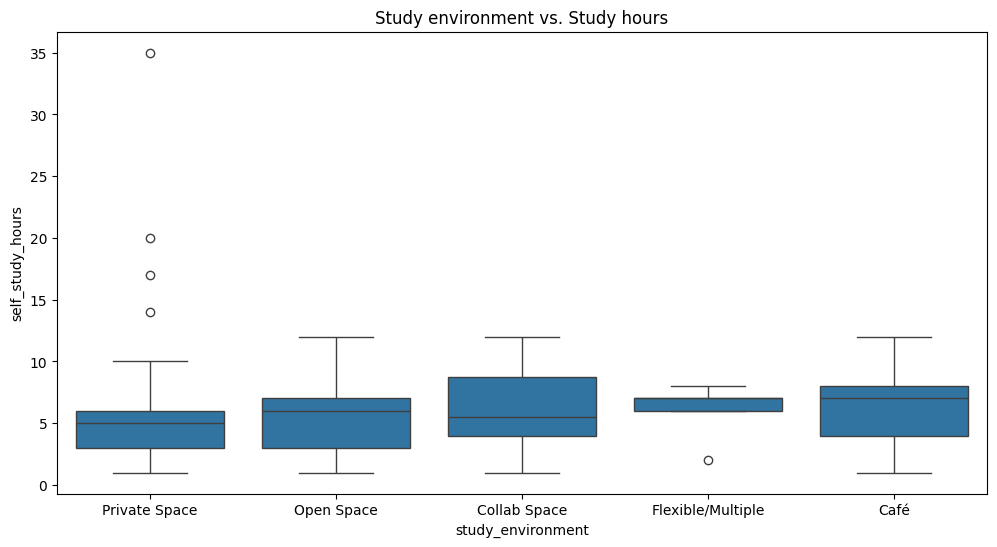

In [9]:
# plot study environment vs study hours
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='study_environment', y='self_study_hours')
plt.title('Study environment vs. Study hours')
plt.show()